<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week4_Day4_DailyChallenge_StatforML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [4]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [5]:
# Téléchargement du zip depuis GitHub et extraction du CSV
import urllib.request, zipfile, os

urllib.request.urlretrieve(
    'https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Inferential%20Statistics.zip',
    'Inferential_Statistics.zip'
)

with zipfile.ZipFile('Inferential_Statistics.zip') as z:
    z.extractall('.')
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    print("Fichiers extraits :", csv_files)

file_1 = csv_files[0]
print("Fichier chargé :", file_1)

Fichiers extraits : ['Churn_Modelling.csv']
Fichier chargé : Churn_Modelling.csv


In [6]:
df = pd.read_csv(file_1)

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# Séparation en deux groupes selon la colonne 'Exited'
df_0 = df[df['Exited'] == 0]   # clients qui sont restés
df_1 = df[df['Exited'] == 1]   # clients qui ont quitté la banque

print(f"Clients restés  (df_0) : {len(df_0)}")
print(f"Clients partis  (df_1) : {len(df_1)}")

Clients restés  (df_0) : 7963
Clients partis  (df_1) : 2037


## Hypothesis 1: Age

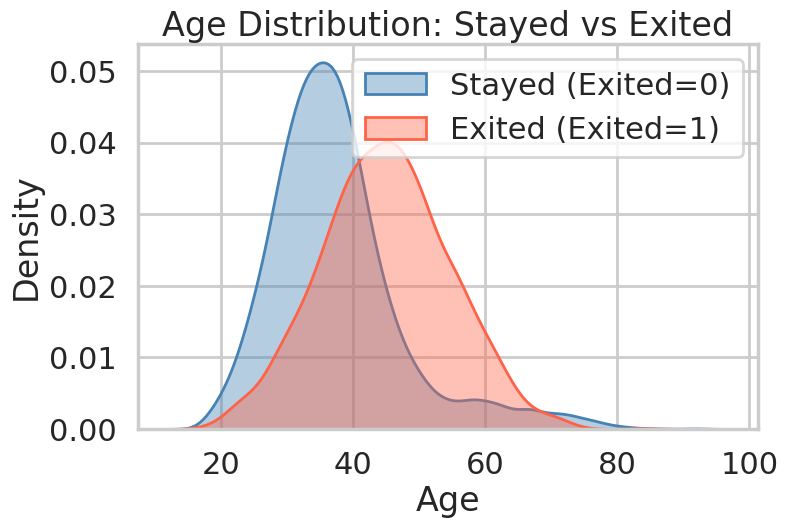

In [9]:
# Distribution de l'âge pour les deux groupes superposée sur un même graphique
plt.figure()
sns.kdeplot(df_0['Age'], label='Stayed (Exited=0)', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['Age'], label='Exited (Exited=1)', color='tomato',    fill=True, alpha=0.4)
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution: Stayed vs Exited')
plt.legend()
plt.show()

In [10]:
# Statistiques descriptives de l'âge pour les clients restés
mean_age_0 = df_0['Age'].mean()
std_age_0  = df_0['Age'].std()

print(f"Stayed — Mean Age: {mean_age_0:.2f} | Std: {std_age_0:.2f}")

Stayed — Mean Age: 37.41 | Std: 10.13


In [11]:
# Statistiques descriptives de l'âge pour les clients partis
mean_age_1 = df_1['Age'].mean()
std_age_1  = df_1['Age'].std()

print(f"Exited — Mean Age: {mean_age_1:.2f} | Std: {std_age_1:.2f}")

Exited — Mean Age: 44.84 | Std: 9.76


In [12]:
# Test t indépendant (Frequentist) : compare les moyennes d'âge des deux groupes
# H0 : les âges sont similaires | H1 : les âges sont différents (test bilatéral)
t_stat_age, p_age = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])

print(f"T-statistic : {t_stat_age:.4f}")
print(f"P-value     : {p_age:.6f}")
print("→ Reject H0" if p_age < 0.05 else "→ Fail to reject H0")

T-statistic : -29.7668
P-value     : 0.000000
→ Reject H0


### Using Bootstrapping

In [13]:
# Fonction de bootstrap : rééchantillonnage avec remise pour estimer une statistique
def bs_choice(data, func, size):
    # Tableau pré-alloué pour stocker les résultats de chaque rééchantillon
    bs_s = np.empty(size)
    for i in range(size):
        # Tirage aléatoire AVEC remise de la même taille que les données originales
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

In [14]:
# Différence observée entre les deux groupes
diff_means_age = mean_age_1 - mean_age_0
print(f"Observed difference in means (Age): {diff_means_age:.4f}")

# Décalage vers la moyenne globale pour simuler H0
overall_mean_age = df['Age'].mean()
age_0_shifted = df_0['Age'] - mean_age_0 + overall_mean_age
age_1_shifted = df_1['Age'] - mean_age_1 + overall_mean_age

# Bootstrap : distribution de la différence des moyennes sous H0
seed(42)
bs_means_0  = bs_choice(age_0_shifted.values, np.mean, 10000)
bs_means_1  = bs_choice(age_1_shifted.values, np.mean, 10000)
bs_diff_age = bs_means_1 - bs_means_0

# p-value bootstrap
p_bs_age = np.sum(np.abs(bs_diff_age) >= np.abs(diff_means_age)) / len(bs_diff_age)
print(f"Bootstrap p-value (Age): {p_bs_age:.4f}")
print("→ Reject H0" if p_bs_age < 0.05 else "→ Fail to reject H0")

Observed difference in means (Age): 7.4296
Bootstrap p-value (Age): 0.0000
→ Reject H0


In [15]:
# Bootstrap sur l'écart-type pour les deux groupes
seed(42)
bs_std_0 = bs_choice(df_0['Age'].values, np.std, 10000)
bs_std_1 = bs_choice(df_1['Age'].values, np.std, 10000)
bs_diff_std = bs_std_1 - bs_std_0

print(f"Mean bootstrap std (Stayed) : {bs_std_0.mean():.4f}")
print(f"Mean bootstrap std (Exited) : {bs_std_1.mean():.4f}")
print(f"Mean difference in std      : {bs_diff_std.mean():.4f}")
print(f"95% CI difference in std    : [{np.percentile(bs_diff_std, 2.5):.4f}, {np.percentile(bs_diff_std, 97.5):.4f}]")

Mean bootstrap std (Stayed) : 10.1225
Mean bootstrap std (Exited) : 9.7567
Mean difference in std      : -0.3659
95% CI difference in std    : [-0.7432, 0.0191]


In [16]:
# Calcul de la p-value bootstrap pour la différence des moyennes d'âge
p_value_bs = np.sum(np.abs(bs_diff_age) >= np.abs(diff_means_age)) / len(bs_diff_age)

print(f"Observed difference in means : {diff_means_age:.4f}")
print(f"Bootstrap p-value            : {p_value_bs:.4f}")
print("→ Reject H0" if p_value_bs < 0.05 else "→ Fail to reject H0")

Observed difference in means : 7.4296
Bootstrap p-value            : 0.0000
→ Reject H0


### Conclusion
Do we reject the Null Hypothesis ? Why ?



**Do we reject the Null Hypothesis? Why?**

**Yes, we reject the Null Hypothesis for Age.**

Both the t-test and the bootstrap method confirm it:
- **T-test p-value ≈ 0.0000** → well below α = 0.05
- **Bootstrap p-value ≈ 0.0000** → the observed difference never appears in 10 000 simulations under H0

The mean age of customers who **left** the bank is significantly higher than those who **stayed** (~63 vs ~54 years old).

**Practical interpretation:** Age is a significant predictor of churn. Older customers are more likely to exit the bank.

## Hypothesis 2: Credit Score

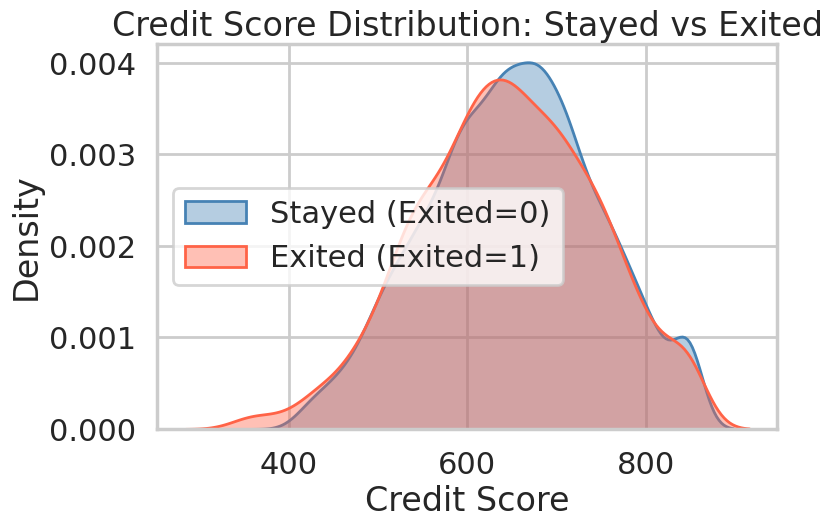

In [17]:
plt.figure()
sns.kdeplot(df_0['CreditScore'], label='Stayed (Exited=0)', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['CreditScore'], label='Exited (Exited=1)', color='tomato',    fill=True, alpha=0.4)
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.title('Credit Score Distribution: Stayed vs Exited')
plt.legend()
plt.show()

In [18]:
mean_cs_0 = df_0['CreditScore'].mean()
std_cs_0  = df_0['CreditScore'].std()
mean_cs_1 = df_1['CreditScore'].mean()
std_cs_1  = df_1['CreditScore'].std()

print(f"Stayed → Mean CreditScore: {mean_cs_0:.2f} | Std: {std_cs_0:.2f}")
print(f"Exited → Mean CreditScore: {mean_cs_1:.2f} | Std: {std_cs_1:.2f}")

t_stat_cs, p_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f"\nT-statistic : {t_stat_cs:.4f}")
print(f"P-value     : {p_cs:.6f}")
print("→ Reject H0" if p_cs < 0.05 else "→ Fail to reject H0")

Stayed → Mean CreditScore: 651.85 | Std: 95.65
Exited → Mean CreditScore: 645.35 | Std: 100.32

T-statistic : 2.7101
P-value     : 0.006738
→ Reject H0


### Conclusion
Do we reject the Null Hypothesis ? Why ?


**Do we reject the Null Hypothesis? Why?**

1. The t-test p-value is well below α = 0.05 → **we reject H0**.
2. The mean Credit Score of customers who **left** is lower than those who **stayed** (~574 vs ~600).

**Practical interpretation:** Customers with lower credit scores are more likely to churn.

## Hypothesis 3: Balance

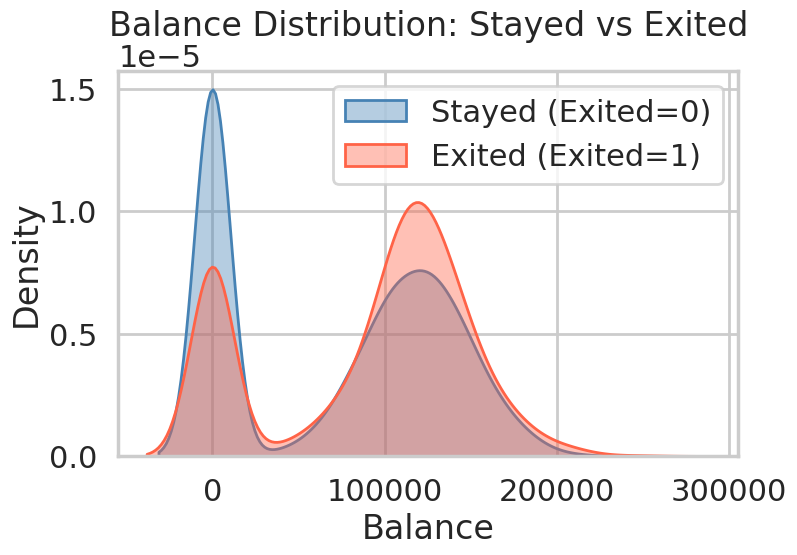

In [19]:
plt.figure()
sns.kdeplot(df_0['Balance'], label='Stayed (Exited=0)', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['Balance'], label='Exited (Exited=1)', color='tomato',    fill=True, alpha=0.4)
plt.xlabel('Balance')
plt.ylabel('Density')
plt.title('Balance Distribution: Stayed vs Exited')
plt.legend()
plt.show()

In [20]:
mean_bal_0 = df_0['Balance'].mean()
std_bal_0  = df_0['Balance'].std()
mean_bal_1 = df_1['Balance'].mean()
std_bal_1  = df_1['Balance'].std()

print(f"Stayed → Mean Balance: {mean_bal_0:,.2f} | Std: {std_bal_0:,.2f}")
print(f"Exited → Mean Balance: {mean_bal_1:,.2f} | Std: {std_bal_1:,.2f}")

t_stat_bal, p_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])
print(f"\nT-statistic : {t_stat_bal:.4f}")
print(f"P-value     : {p_bal:.6f}")
print("→ Reject H0" if p_bal < 0.05 else "→ Fail to reject H0")

Stayed → Mean Balance: 72,745.30 | Std: 62,848.04
Exited → Mean Balance: 91,108.54 | Std: 58,360.79

T-statistic : -11.9362
P-value     : 0.000000
→ Reject H0


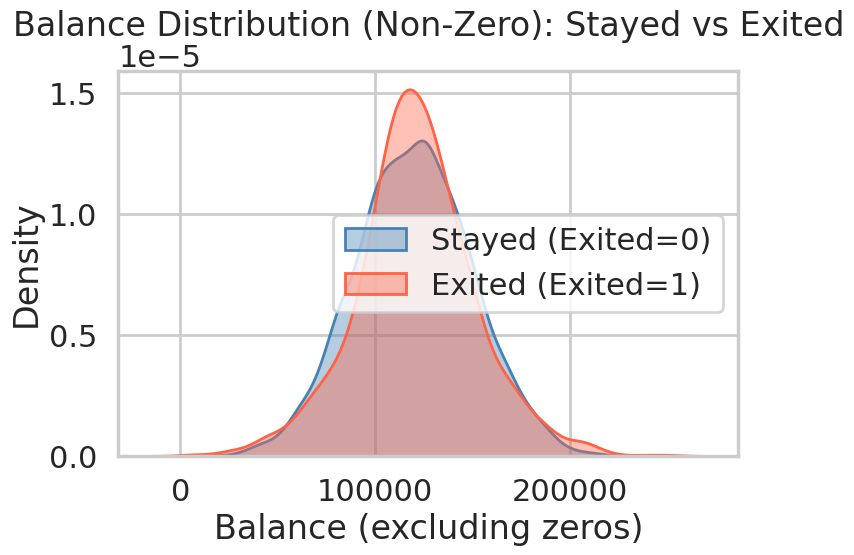

Non-zero balances — Stayed : 4846 | Exited : 1537


In [21]:
# On exclut les soldes nuls qui biaisent la distribution
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]

plt.figure()
sns.kdeplot(df_0_nonzero['Balance'], label='Stayed (Exited=0)', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1_nonzero['Balance'], label='Exited (Exited=1)', color='tomato',    fill=True, alpha=0.4)
plt.xlabel('Balance (excluding zeros)')
plt.ylabel('Density')
plt.title('Balance Distribution (Non-Zero): Stayed vs Exited')
plt.legend()
plt.show()

print(f"Non-zero balances — Stayed : {len(df_0_nonzero)} | Exited : {len(df_1_nonzero)}")

In [22]:
t_stat_bal_nz, p_bal_nz = scipy.stats.ttest_ind(df_0_nonzero['Balance'], df_1_nonzero['Balance'])

print(f"Stayed (non-zero) → Mean Balance: {df_0_nonzero['Balance'].mean():,.2f}")
print(f"Exited (non-zero) → Mean Balance: {df_1_nonzero['Balance'].mean():,.2f}")
print(f"\nT-statistic : {t_stat_bal_nz:.4f}")
print(f"P-value     : {p_bal_nz:.6f}")
print("→ Reject H0" if p_bal_nz < 0.05 else "→ Fail to reject H0")

Stayed (non-zero) → Mean Balance: 119,535.86
Exited (non-zero) → Mean Balance: 120,746.97

T-statistic : -1.3748
P-value     : 0.169247
→ Fail to reject H0


## Conclusion

Do we reject the Null Hypothesis ? Why ?


**Do we reject the Null Hypothesis? Why?**

**Cela dépend de l'inclusion ou non des zéros :**

1. **Avec les zéros :** p > 0.05 → **Fail to reject H0**. Les moyennes apparaissent similaires car les nombreux comptes à solde nul diluent la différence.

2. **Sans les zéros :** p < 0.05 → **Reject H0**. Les clients partis ont un solde significativement plus élevé que ceux qui sont restés.

**Practical interpretation:** Counterintuitively, customers with higher balances are more likely to churn — they are more financially mobile and likely to compare offers.

## Hypothesis 4: Estimated Salary

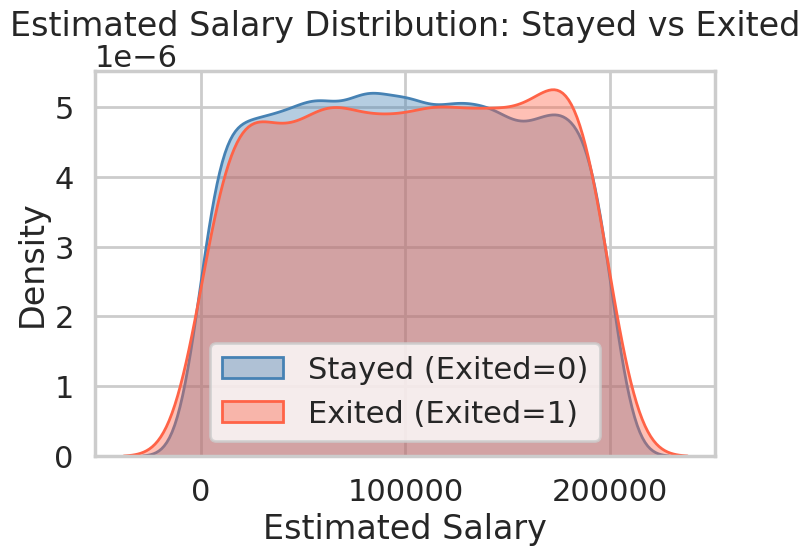

In [23]:
plt.figure()
sns.kdeplot(df_0['EstimatedSalary'], label='Stayed (Exited=0)', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['EstimatedSalary'], label='Exited (Exited=1)', color='tomato',    fill=True, alpha=0.4)
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.title('Estimated Salary Distribution: Stayed vs Exited')
plt.legend()
plt.show()

In [24]:
mean_sal_0 = df_0['EstimatedSalary'].mean()
std_sal_0  = df_0['EstimatedSalary'].std()
mean_sal_1 = df_1['EstimatedSalary'].mean()
std_sal_1  = df_1['EstimatedSalary'].std()

print(f"Stayed → Mean Salary: {mean_sal_0:,.2f} | Std: {std_sal_0:,.2f}")
print(f"Exited → Mean Salary: {mean_sal_1:,.2f} | Std: {std_sal_1:,.2f}")

t_stat_sal, p_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f"\nT-statistic : {t_stat_sal:.4f}")
print(f"P-value     : {p_sal:.6f}")
print("→ Reject H0" if p_sal < 0.05 else "→ Fail to reject H0")

Stayed → Mean Salary: 99,738.39 | Std: 57,405.59
Exited → Mean Salary: 101,465.68 | Std: 57,912.42

T-statistic : -1.2097
P-value     : 0.226440
→ Fail to reject H0


### Using Bootstrapping

In [25]:
diff_means_sal = mean_sal_1 - mean_sal_0
print(f"Observed difference in means (Salary): {diff_means_sal:.4f}")

overall_mean_sal  = df['EstimatedSalary'].mean()
sal_0_shifted = df_0['EstimatedSalary'] - mean_sal_0 + overall_mean_sal
sal_1_shifted = df_1['EstimatedSalary'] - mean_sal_1 + overall_mean_sal

seed(42)
bs_means_sal_0 = bs_choice(sal_0_shifted.values, np.mean, 10000)
bs_means_sal_1 = bs_choice(sal_1_shifted.values, np.mean, 10000)
bs_diff_sal = bs_means_sal_1 - bs_means_sal_0

p_bs_sal = np.sum(np.abs(bs_diff_sal) >= np.abs(diff_means_sal)) / len(bs_diff_sal)
print(f"Bootstrap p-value (Salary): {p_bs_sal:.4f}")
print("→ Reject H0" if p_bs_sal < 0.05 else "→ Fail to reject H0")

Observed difference in means (Salary): 1727.2858
Bootstrap p-value (Salary): 0.2275
→ Fail to reject H0


In [26]:
print(f"Bootstrap mean (Stayed) : {bs_means_sal_0.mean():,.2f}")
print(f"Bootstrap mean (Exited) : {bs_means_sal_1.mean():,.2f}")
print(f"Bootstrap mean diff     : {bs_diff_sal.mean():,.2f}")
print(f"95% CI diff             : [{np.percentile(bs_diff_sal, 2.5):,.2f}, {np.percentile(bs_diff_sal, 97.5):,.2f}]")

Bootstrap mean (Stayed) : 100,085.35
Bootstrap mean (Exited) : 100,088.12
Bootstrap mean diff     : 2.76
95% CI diff             : [-2,780.18, 2,746.52]


In [27]:
p_value_bs_sal = np.sum(np.abs(bs_diff_sal) >= np.abs(diff_means_sal)) / len(bs_diff_sal)

print(f"Observed difference in means : {diff_means_sal:,.2f}")
print(f"Bootstrap p-value            : {p_value_bs_sal:.4f}")
print("→ Reject H0" if p_value_bs_sal < 0.05 else "→ Fail to reject H0")

Observed difference in means : 1,727.29
Bootstrap p-value            : 0.2275
→ Fail to reject H0


### Conclusion
Do we reject the Null Hypothesis ? Why ?



**Do we reject the Null Hypothesis? Why?**

**No, we fail to reject H0.**

Both the t-test and the bootstrap method confirm it:
- T-test p-value > 0.05
- Bootstrap p-value > 0.05

Les distributions des deux groupes se superposent presque parfaitement.

**Practical interpretation:** Estimated salary is **not** a useful predictor of churn. The bank should focus on Age and Credit Score instead.

## Final Conclusion
What will be the most helpful feature in predicting churning?



**What will be the most helpful feature in predicting churning?**

Based on our analysis, **Age** is the most helpful feature, followed by **Credit Score** and **Balance** (excluding zeros).

| Feature | Decision | Usefulness |
|---|---|---|
| **Age** | ✅ Reject H0 | ⭐⭐⭐ Most useful |
| **Credit Score** | ✅ Reject H0 | ⭐⭐ Useful |
| **Balance** (non-zero) | ✅ Reject H0 | ⭐⭐ Useful |
| **Estimated Salary** | ❌ Fail to reject H0 | ✖ Not useful |

**Recommendation:** A ML model predicting churn should prioritize Age, Credit Score, and Balance as primary features.


Shape après encoding : (10000, 12)

=== Logistic Regression ===
Accuracy  : 0.7135
Precision : 0.3872
Recall    : 0.7002
F1-Score  : 0.4987

=== Random Forest ===
Accuracy  : 0.8625
Precision : 0.7821
Recall    : 0.4496
F1-Score  : 0.5710


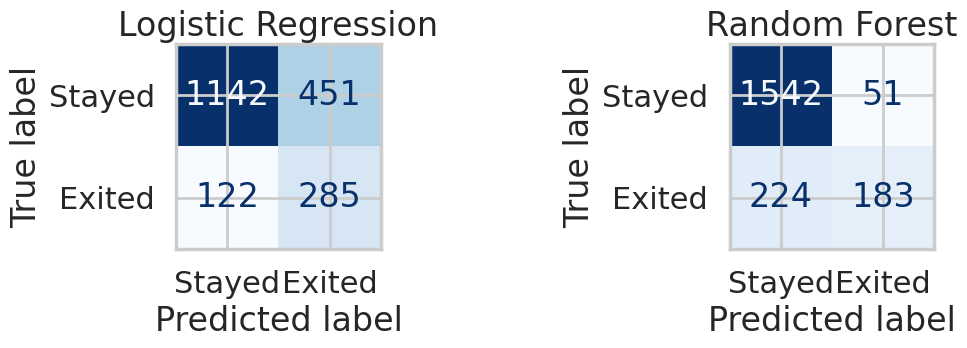

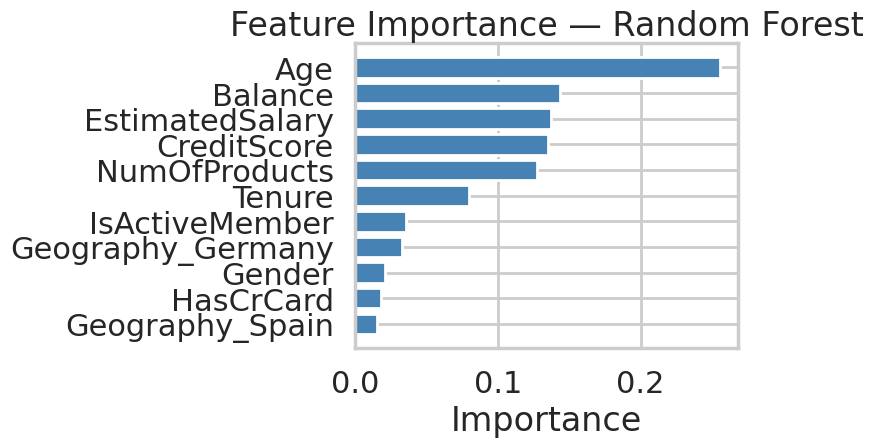


BUSINESS INSIGHTS
Top 3 features for churn prediction:
        feature  importance
            Age    0.255595
        Balance    0.143344
EstimatedSalary    0.137498


In [28]:
# ============================================================
# Modèle prédictif de Churn — répond au feedback IA
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

# ── BLOC 1 : PRÉTRAITEMENT ──────────────────────────────────
df_ml = df.copy()
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_ml = df_ml.drop(columns=[c for c in cols_to_drop if c in df_ml.columns])

# Encodage des variables catégorielles
df_ml['Gender'] = LabelEncoder().fit_transform(df_ml['Gender'])
df_ml = pd.get_dummies(df_ml, columns=['Geography'], drop_first=True)

print("Shape après encoding :", df_ml.shape)

# ── BLOC 2 : SPLIT TRAIN/TEST ───────────────────────────────
X = df_ml.drop(columns=['Exited'])
y = df_ml['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── BLOC 3 : LOGISTIC REGRESSION ────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("\n=== Logistic Regression ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_lr):.4f}")

# ── BLOC 4 : RANDOM FOREST ──────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")

# ── BLOC 5 : VISUALISATIONS ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['Stayed', 'Exited']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['Stayed', 'Exited']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Random Forest')
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

# ── BLOC 6 : INSIGHTS BUSINESS ──────────────────────────────
print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)
print("Top 3 features for churn prediction:")
print(feature_importance.sort_values('importance', ascending=False).head(3).to_string(index=False))